In [9]:
import os
os.chdir('..')

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.io
from scipy.signal import resample_poly

from src.data.cwru_data import cwru_load_data

# Drive-End

In [41]:
b_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat"
b_signal = scipy.io.loadmat(b_path)['X118_DE_time'].squeeze()

ir_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data\IR\007\105_0.mat"
ir_signal = scipy.io.loadmat(ir_path)['X105_DE_time'].squeeze()

or_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\130@6_0.mat"
or_signal = scipy.io.loadmat(or_path)['X130_DE_time'].squeeze()

n_path = r"D:\Capstone\dataset\raw\CWRU\Normal\100_Normal_3.mat"
n_signal = scipy.io.loadmat(n_path)['X100_DE_time'].squeeze()
n_signal = resample_poly(n_signal, 1, 4)

faults = [or_signal, ir_signal, b_signal, n_signal]
labels = ["Outer Race", "Inner Race", "Ball", "Normal"]

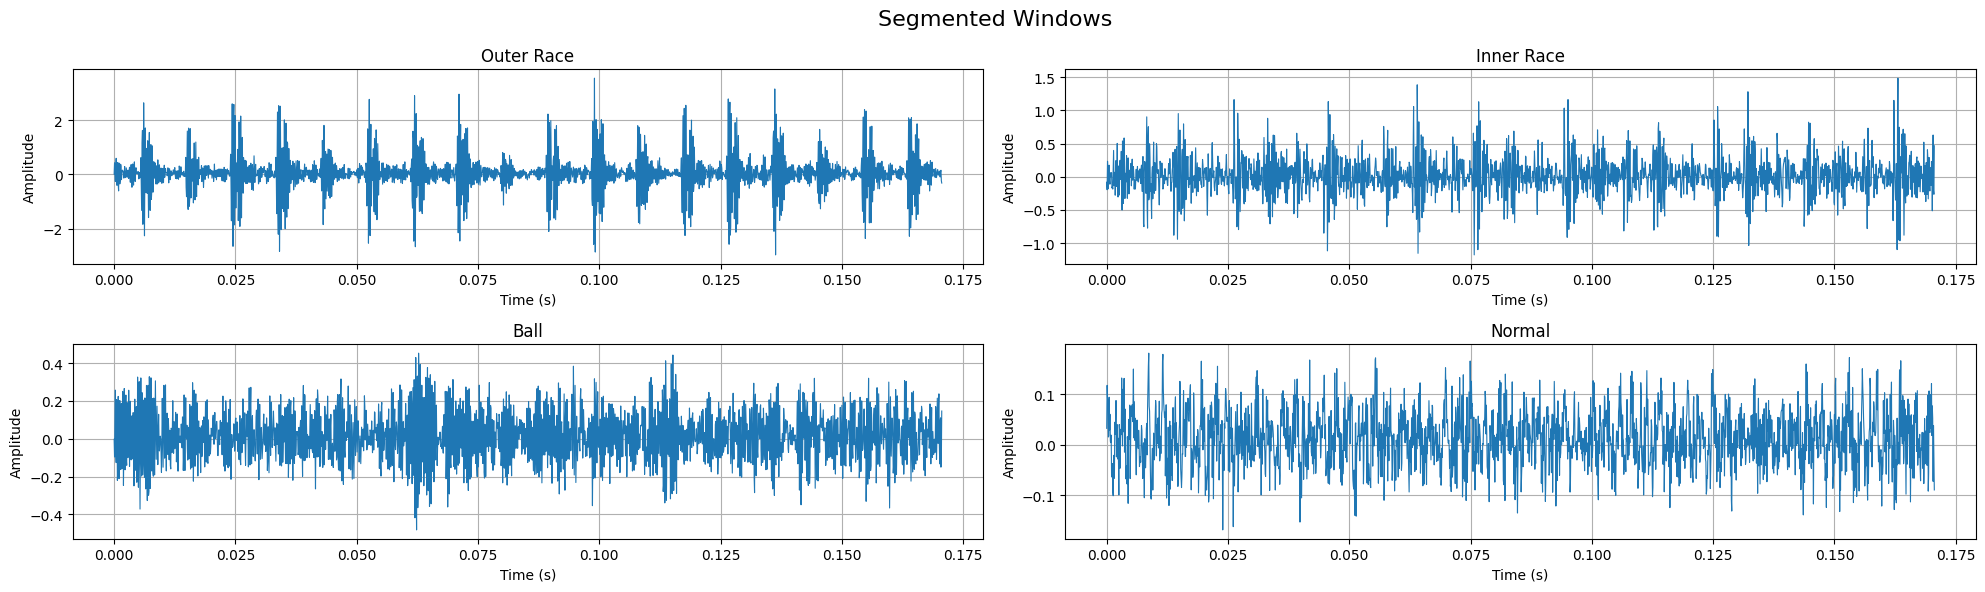

In [48]:
fs = 12000

fig, axes = plt.subplots(2, 2, figsize=(20, 6))
fig.suptitle("Segmented Windows", fontsize=16)
axes = axes.flatten()

for i, (signal, label) in enumerate(zip(faults, labels)):
    
    sig = signal[:2048]
    t = np.arange(len(sig)) / fs
    
    axes[i].plot(t, sig, linewidth=0.8)
    axes[i].set_title(label)
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Fan-End

In [36]:
b_path = r"D:\Capstone\dataset\raw\CWRU\12k_Fan_End_Bearing_Fault_Data\B\007\285_3.mat"
b_signal = scipy.io.loadmat(b_path)['X285_FE_time'].squeeze()

ir_path = r"D:\Capstone\dataset\raw\CWRU\12k_Fan_End_Bearing_Fault_Data\IR\007\278_0.mat"
ir_signal = scipy.io.loadmat(ir_path)['X278_FE_time'].squeeze()

or_path = r"D:\Capstone\dataset\raw\CWRU\12k_Fan_End_Bearing_Fault_Data\OR\007\@6\294_0.mat"
or_signal = scipy.io.loadmat(or_path)['X294_FE_time'].squeeze()

n_path = r"D:\Capstone\dataset\raw\CWRU\Normal\100_Normal_3.mat"
n_signal = scipy.io.loadmat(n_path)['X100_FE_time'].squeeze()
n_signal = resample_poly(n_signal, 1, 4)

faults = [or_signal, ir_signal, b_signal, n_signal]
labels = ["Outer Race", "Inner Race", "Ball", "Normal"]

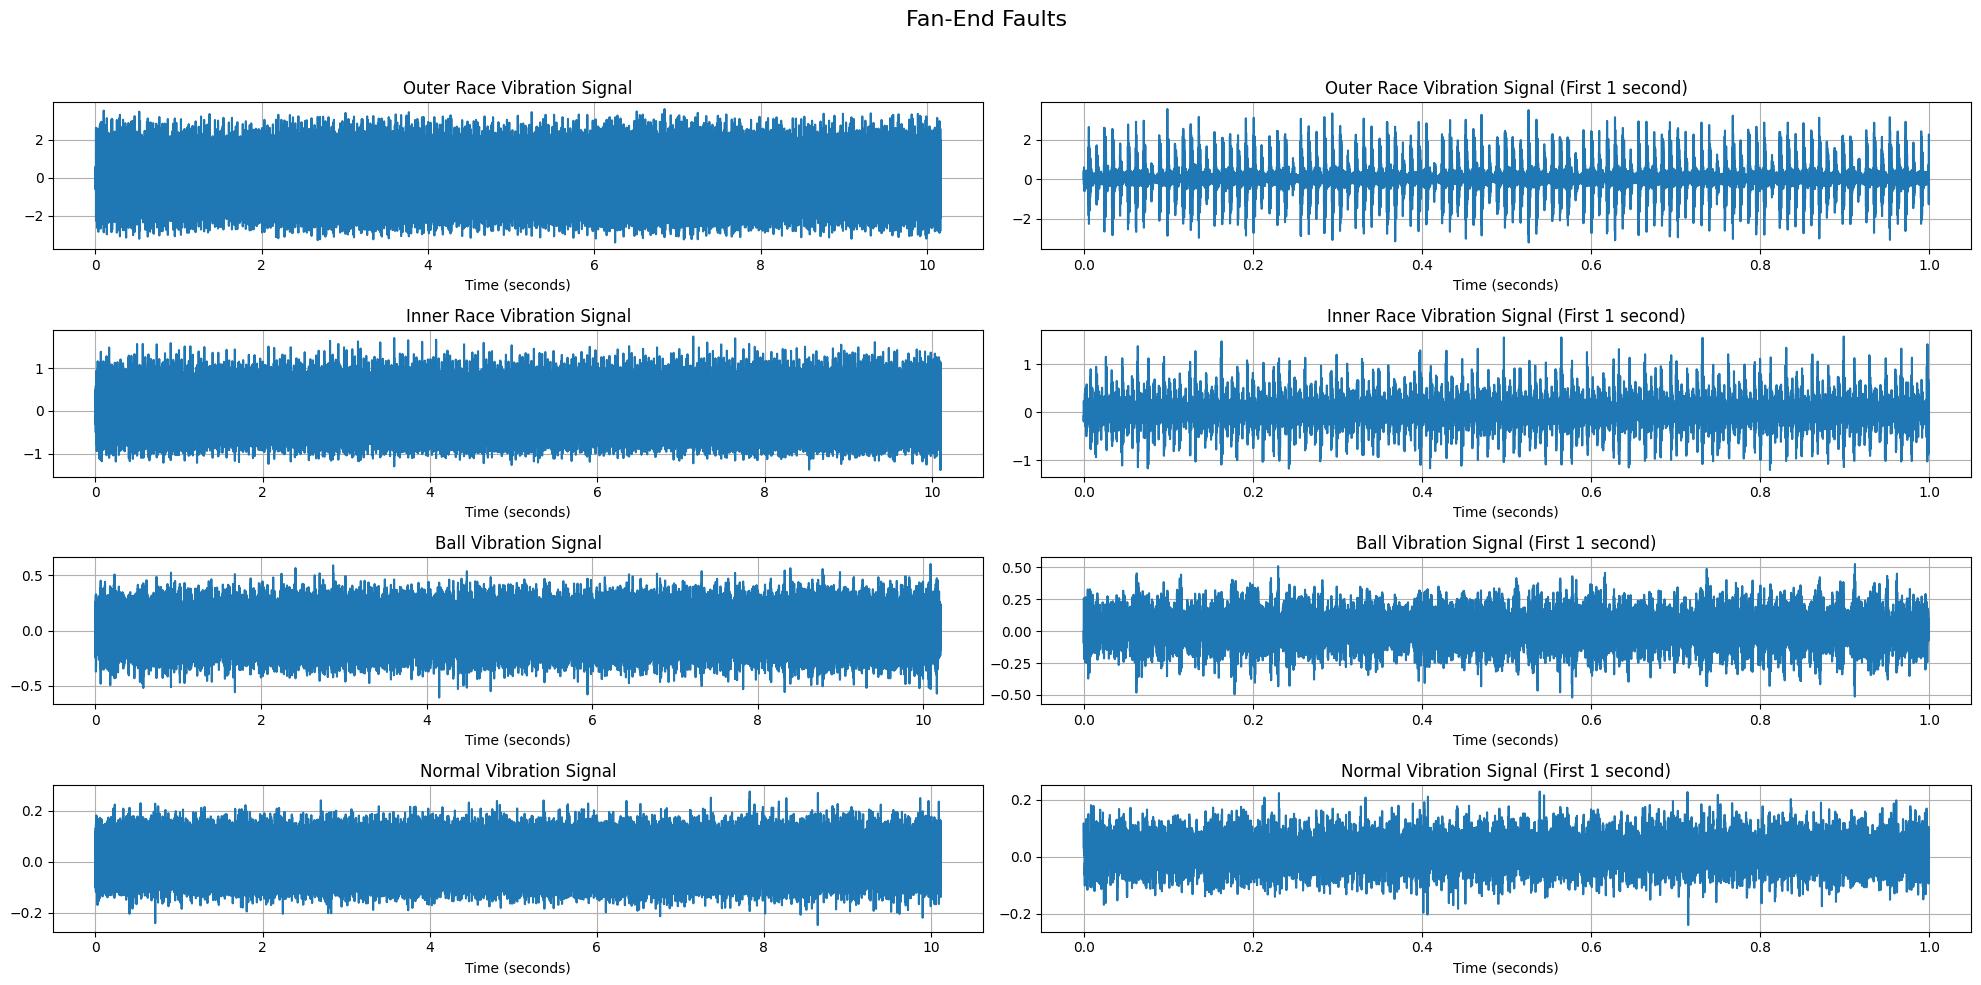

In [44]:
fs = 12000

fig, axes = plt.subplots(len(faults), 2, figsize=(20, 10))
fig.suptitle("Fan-End Faults", fontsize=16)

for i, (signal, label) in enumerate(zip(faults, labels)):

    t_full = np.arange(len(signal)) / fs

    axes[i, 0].plot(t_full, signal)
    axes[i, 0].set_title(f"{label} Vibration Signal")
    axes[i, 0].set_xlabel("Time (seconds)")
    axes[i, 0].grid(True)

    one_sec_samples = fs
    signal_1s = signal[:one_sec_samples]
    t_1s = np.arange(len(signal_1s)) / fs

    axes[i, 1].plot(t_1s, signal_1s)
    axes[i, 1].set_title(f"{label} Vibration Signal (First 1 second)")
    axes[i, 1].set_xlabel("Time (seconds)")
    axes[i, 1].grid(True)
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()